In [9]:

pip install faker


### Patient Risk Classification

In [10]:
# Define risk thresholds based on general medical guidelines (these are illustrative and can be adjusted)
def classify_risk(patient):
    risk_score = 0

    # Blood Pressure
    if patient['blood_pressure_systolic'] >= 140 or patient['blood_pressure_diastolic'] >= 90:
        risk_score += 2 # High BP
    elif patient['blood_pressure_systolic'] >= 120 or patient['blood_pressure_diastolic'] >= 80:
        risk_score += 1 # Elevated BP

    # Sugar Level
    if patient['sugar_level_mg_dL'] >= 126:
        risk_score += 2 # Diabetic
    elif patient['sugar_level_mg_dL'] >= 100:
        risk_score += 1 # Pre-diabetic

    # Cholesterol
    if patient['total_cholesterol_mg_dL'] >= 240 or patient['ldl_cholesterol_mg_dL'] >= 160 or patient['hdl_cholesterol_mg_dL'] < 40:
        risk_score += 2 # High cholesterol
    elif patient['total_cholesterol_mg_dL'] >= 200 or patient['ldl_cholesterol_mg_dL'] >= 130 or patient['hdl_cholesterol_mg_dL'] < 50:
        risk_score += 1 # Borderline high cholesterol

    # Heart Rate
    if patient['heart_rate_bpm'] < 60 or patient['heart_rate_bpm'] > 100:
        risk_score += 1 # Abnormal heart rate

    if risk_score >= 4:
        return 'High Risk'
    elif risk_score >= 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Apply the risk classification function to each patient record
df_patients['risk_category'] = df_patients.apply(classify_risk, axis=1)

print("Risk category distribution:")
display(df_patients['risk_category'].value_counts())

# Display a few patients with their assigned risk categories
print("\nSample patients with risk categories:")
display(df_patients[['patient_id', 'age', 'gender', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'sugar_level_mg_dL', 'total_cholesterol_mg_dL', 'heart_rate_bpm', 'risk_category']].head())

Risk category distribution:


,count
risk_category,
High Risk,7801
Medium Risk,2025
Low Risk,174



Sample patients with risk categories:


,patient_id,age,gender,blood_pressure_systolic,blood_pressure_diastolic,sugar_level_mg_dL,total_cholesterol_mg_dL,heart_rate_bpm,risk_category
0,37eb1a71-c2e4-44d6-96e2-d5b76cd2ce5c,39,Male,93,98,162.4,237,72,High Risk
1,07c0ccdc-409e-4df0-94a6-63ce51255648,27,Female,180,105,145.7,163,91,High Risk
2,3ac0e837-1d85-4eed-9444-d2fcf392f16f,68,Female,152,76,180.4,260,75,High Risk
3,14734150-c6af-4cdb-800e-1dbb3f3599c5,44,Female,142,87,84.8,197,67,High Risk
4,6eb0f601-8d5e-4f0c-a61e-10cff5205cff,81,Male,173,96,83.3,163,67,Medium Risk


### Identifying High-Risk Patients

In [11]:
high_risk_patients = df_patients[df_patients['risk_category'] == 'High Risk']
print(f"Number of high-risk patients: {len(high_risk_patients)}")
print("\nDetails of a few high-risk patients:")
display(high_risk_patients.head())

Number of high-risk patients: 7801

Details of a few high-risk patients:


,patient_id,age,gender,blood_pressure_systolic,blood_pressure_diastolic,sugar_level_mg_dL,total_cholesterol_mg_dL,hdl_cholesterol_mg_dL,ldl_cholesterol_mg_dL,heart_rate_bpm,risk_category
0,37eb1a71-c2e4-44d6-96e2-d5b76cd2ce5c,39,Male,93,98,162.4,237,73,91,72,High Risk
1,07c0ccdc-409e-4df0-94a6-63ce51255648,27,Female,180,105,145.7,163,62,97,91,High Risk
2,3ac0e837-1d85-4eed-9444-d2fcf392f16f,68,Female,152,76,180.4,260,54,73,75,High Risk
3,14734150-c6af-4cdb-800e-1dbb3f3599c5,44,Female,142,87,84.8,197,31,113,67,High Risk
5,8540c484-c2c2-4213-942b-9b7925126688,53,Male,106,112,168.1,256,73,94,87,High Risk


In [12]:
import pandas as pd
from faker import Faker
import random

# Initialize Faker
faker = Faker()

In [13]:
def generate_patient_record():
    gender = random.choice(['Male', 'Female'])
    age = random.randint(18, 90)

    # Realistic blood pressure values
    systolic = random.randint(90, 180)
    diastolic = random.randint(60, 120)

    # Realistic sugar levels (mg/dL)
    sugar_level = round(random.uniform(70.0, 200.0), 1)

    # Realistic cholesterol levels (mg/dL)
    total_cholesterol = random.randint(150, 280)
    hdl_cholesterol = random.randint(30, 80)
    ldl_cholesterol = random.randint(70, 190)

    # Realistic heart rate (beats per minute)
    heart_rate = random.randint(60, 100)

    return {
        'patient_id': faker.uuid4(),
        'age': age,
        'gender': gender,
        'blood_pressure_systolic': systolic,
        'blood_pressure_diastolic': diastolic,
        'sugar_level_mg_dL': sugar_level,
        'total_cholesterol_mg_dL': total_cholesterol,
        'hdl_cholesterol_mg_dL': hdl_cholesterol,
        'ldl_cholesterol_mg_dL': ldl_cholesterol,
        'heart_rate_bpm': heart_rate
    }

In [14]:
# Generate a large dataset (e.g., 10,000 records)
num_records = 10000
patient_data = [generate_patient_record() for _ in range(num_records)]

df_patients = pd.DataFrame(patient_data)

In [15]:
print(f"Generated dataset with {len(df_patients)} records.")
display(df_patients.head())
print(df_patients.info())

Generated dataset with 10000 records.


,patient_id,age,gender,blood_pressure_systolic,blood_pressure_diastolic,sugar_level_mg_dL,total_cholesterol_mg_dL,hdl_cholesterol_mg_dL,ldl_cholesterol_mg_dL,heart_rate_bpm
0,bfefbd5b-dcf0-45c2-9ec0-b78d20dd41a1,58,Female,108,66,93.8,187,38,105,75
1,26ea72b1-4019-4faa-afaf-fee93f8d69cd,39,Female,150,74,140.0,173,80,178,73
2,c274a051-b2ea-49dd-b06f-1e801916efb8,32,Female,103,80,153.5,255,75,170,67
3,96d6e400-f651-4c12-8f6a-e416d77ca829,45,Female,102,72,198.4,230,55,107,73
4,e4239c03-0beb-41e3-83fb-1e67d11850bd,21,Male,177,67,149.2,150,54,82,94


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                10000 non-null  object 
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  object 
 3   blood_pressure_systolic   10000 non-null  int64  
 4   blood_pressure_diastolic  10000 non-null  int64  
 5   sugar_level_mg_dL         10000 non-null  float64
 6   total_cholesterol_mg_dL   10000 non-null  int64  
 7   hdl_cholesterol_mg_dL     10000 non-null  int64  
 8   ldl_cholesterol_mg_dL     10000 non-null  int64  
 9   heart_rate_bpm            10000 non-null  int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 781.4+ KB
None


In [16]:
# Check for missing values
missing_values = df_patients.isnull().sum()
print("Missing values in each column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\nMissing values found. Further action might be required.")

Missing values in each column:


,0



No missing values found in the dataset.


In [17]:
# Verify data types (already done with df_patients.info(), but explicitly confirm)
print("\nData types:")
display(df_patients.dtypes)


Data types:


,0
patient_id,object
age,int64
gender,object
blood_pressure_systolic,int64
blood_pressure_diastolic,int64
sugar_level_mg_dL,float64
total_cholesterol_mg_dL,int64
hdl_cholesterol_mg_dL,int64
ldl_cholesterol_mg_dL,int64
heart_rate_bpm,int64


In [18]:
# Summary statistics for numerical columns to check ranges and potential outliers
display(df_patients.describe())

,age,blood_pressure_systolic,blood_pressure_diastolic,sugar_level_mg_dL,total_cholesterol_mg_dL,hdl_cholesterol_mg_dL,ldl_cholesterol_mg_dL,heart_rate_bpm
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54.07100,134.743800,90.247500,134.591830,215.134800,54.761600,129.986800,79.841200
std,21.05863,26.449906,17.655821,37.542984,37.684791,14.751357,34.727718,11.875609
min,18.00000,90.000000,60.000000,70.000000,150.000000,30.000000,70.000000,60.000000
25%,36.00000,112.000000,75.000000,102.300000,182.000000,42.000000,100.000000,70.000000
50%,54.00000,135.000000,90.000000,134.550000,216.000000,55.000000,130.000000,80.000000
75%,72.00000,158.000000,106.000000,167.025000,248.000000,68.000000,160.000000,90.000000
max,90.00000,180.000000,120.000000,200.000000,280.000000,80.000000,190.000000,100.000000


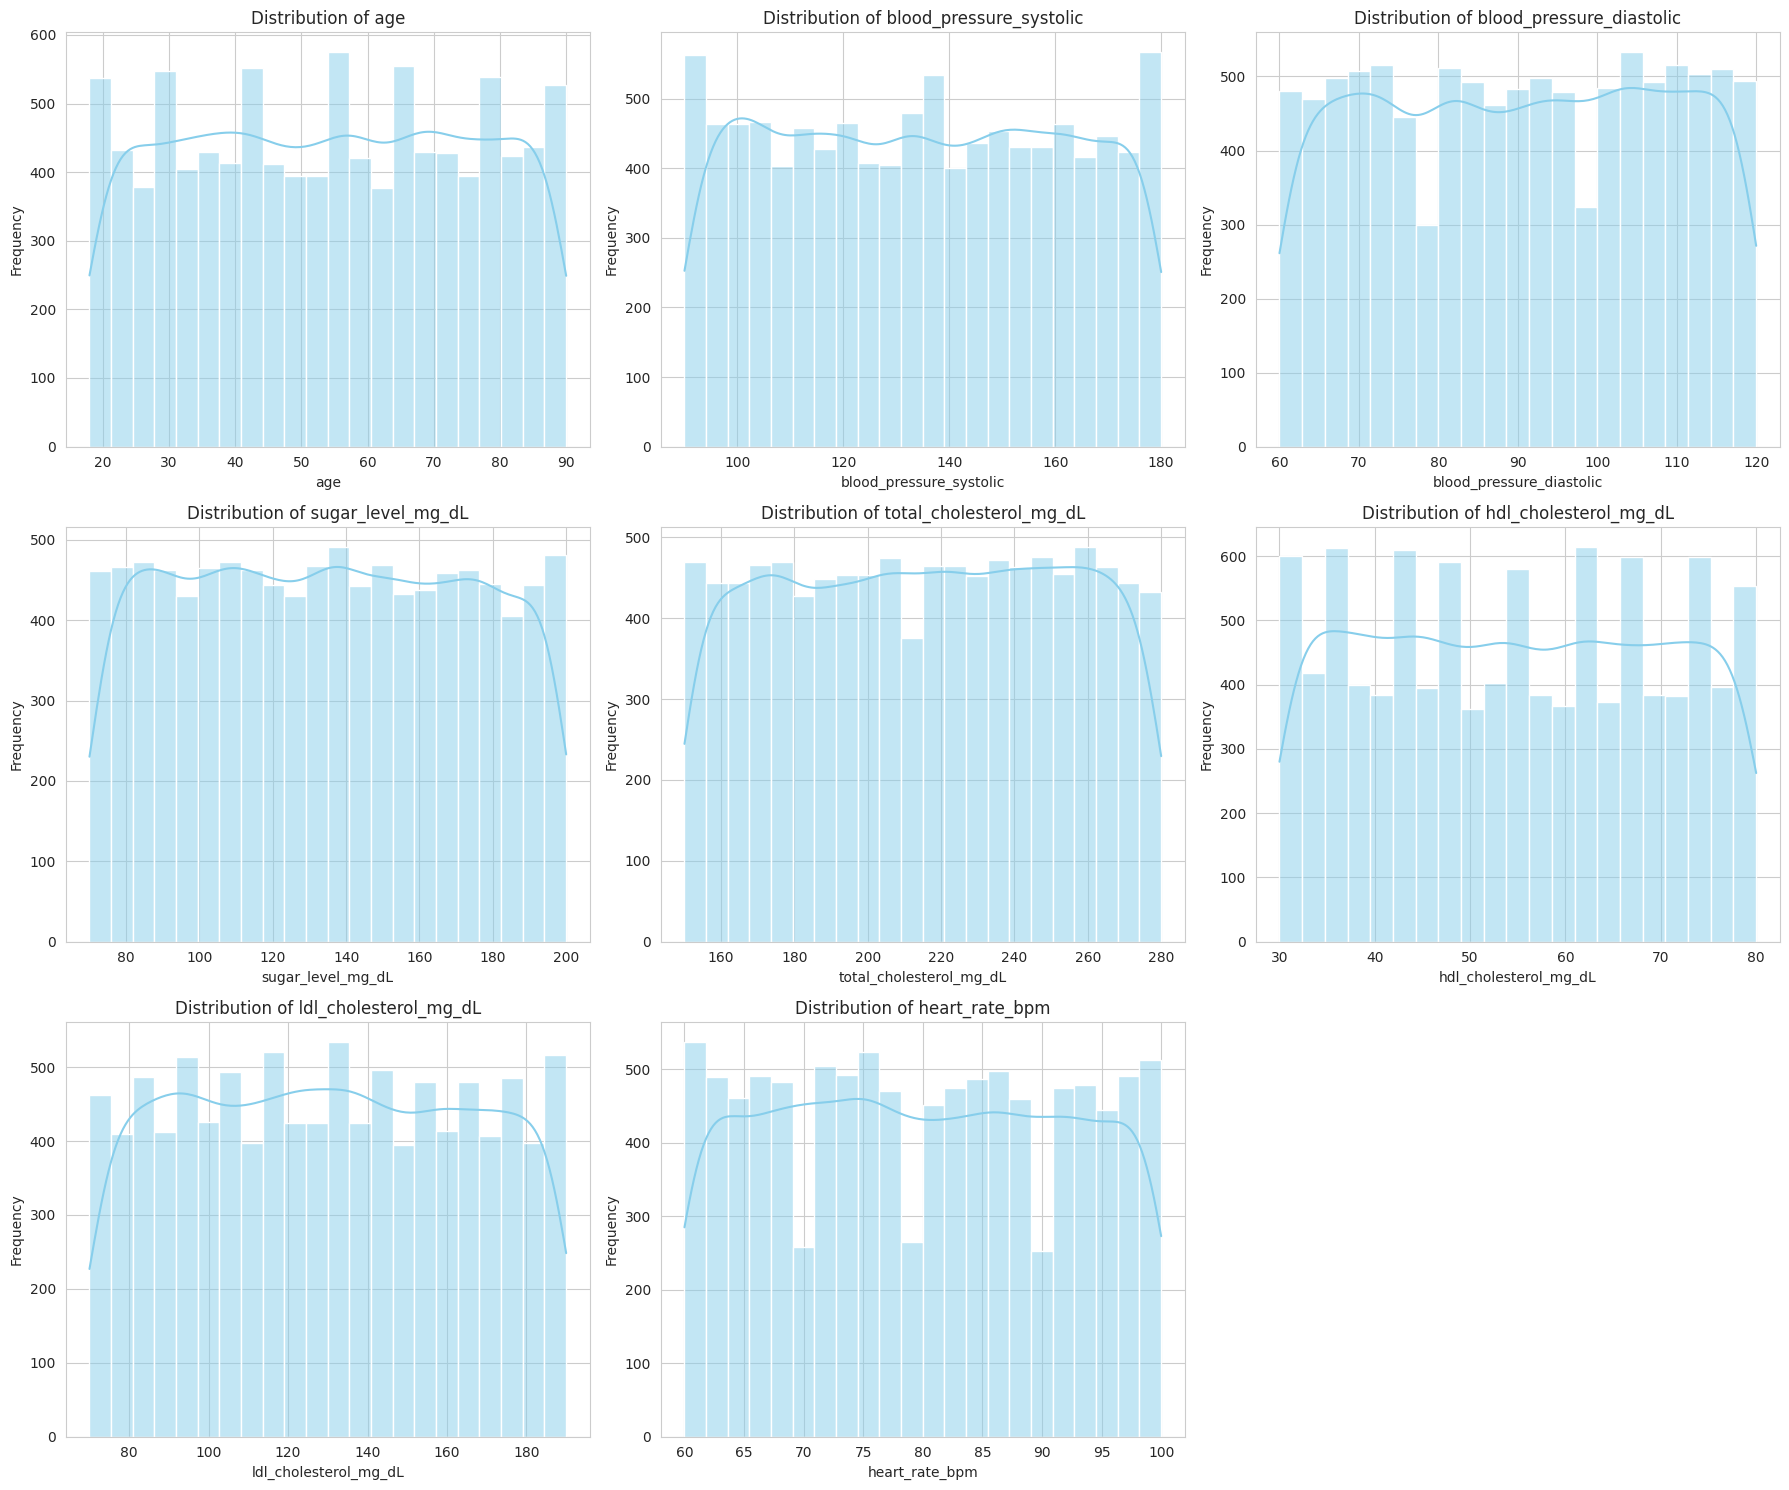

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Create subplots for numerical features distributions
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

numerical_cols = ['age', 'blood_pressure_systolic', 'blood_pressure_diastolic',
                  'sugar_level_mg_dL', 'total_cholesterol_mg_dL',
                  'hdl_cholesterol_mg_dL', 'ldl_cholesterol_mg_dL', 'heart_rate_bpm']

for i, col in enumerate(numerical_cols):
    sns.histplot(df_patients[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_860/3912379.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_patients, palette='viridis')


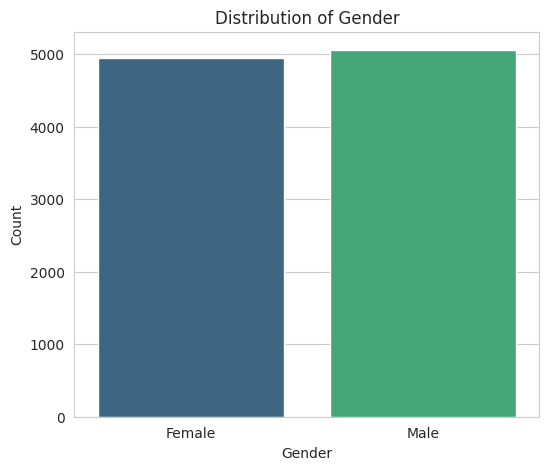

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(x='gender', data=df_patients, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [21]:
print("\nDescriptive statistics for Blood Pressure (Systolic and Diastolic):")
display(df_patients[['blood_pressure_systolic', 'blood_pressure_diastolic']].describe())

print("\nDescriptive statistics for Sugar Levels:")
display(df_patients['sugar_level_mg_dL'].describe())

print("\nDescriptive statistics for Cholesterol Levels (Total, HDL, LDL):")
display(df_patients[['total_cholesterol_mg_dL', 'hdl_cholesterol_mg_dL', 'ldl_cholesterol_mg_dL']].describe())

print("\nDescriptive statistics for Heart Rate:")
display(df_patients['heart_rate_bpm'].describe())


Descriptive statistics for Blood Pressure (Systolic and Diastolic):


,blood_pressure_systolic,blood_pressure_diastolic
count,10000.000000,10000.000000
mean,134.743800,90.247500
std,26.449906,17.655821
min,90.000000,60.000000
25%,112.000000,75.000000
50%,135.000000,90.000000
75%,158.000000,106.000000
max,180.000000,120.000000



Descriptive statistics for Sugar Levels:


,sugar_level_mg_dL
count,10000.000000
mean,134.591830
std,37.542984
min,70.000000
25%,102.300000
50%,134.550000
75%,167.025000
max,200.000000



Descriptive statistics for Cholesterol Levels (Total, HDL, LDL):


,total_cholesterol_mg_dL,hdl_cholesterol_mg_dL,ldl_cholesterol_mg_dL
count,10000.000000,10000.000000,10000.000000
mean,215.134800,54.761600,129.986800
std,37.684791,14.751357,34.727718
min,150.000000,30.000000,70.000000
25%,182.000000,42.000000,100.000000
50%,216.000000,55.000000,130.000000
75%,248.000000,68.000000,160.000000
max,280.000000,80.000000,190.000000



Descriptive statistics for Heart Rate:


,heart_rate_bpm
count,10000.000000
mean,79.841200
std,11.875609
min,60.000000
25%,70.000000
50%,80.000000
75%,90.000000
max,100.000000


/tmp/ipykernel_860/1274732189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_860/1274732189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_860/1274732189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_860/1274732189.py:10: FutureWarning: 

Passing `palette` without assigning `

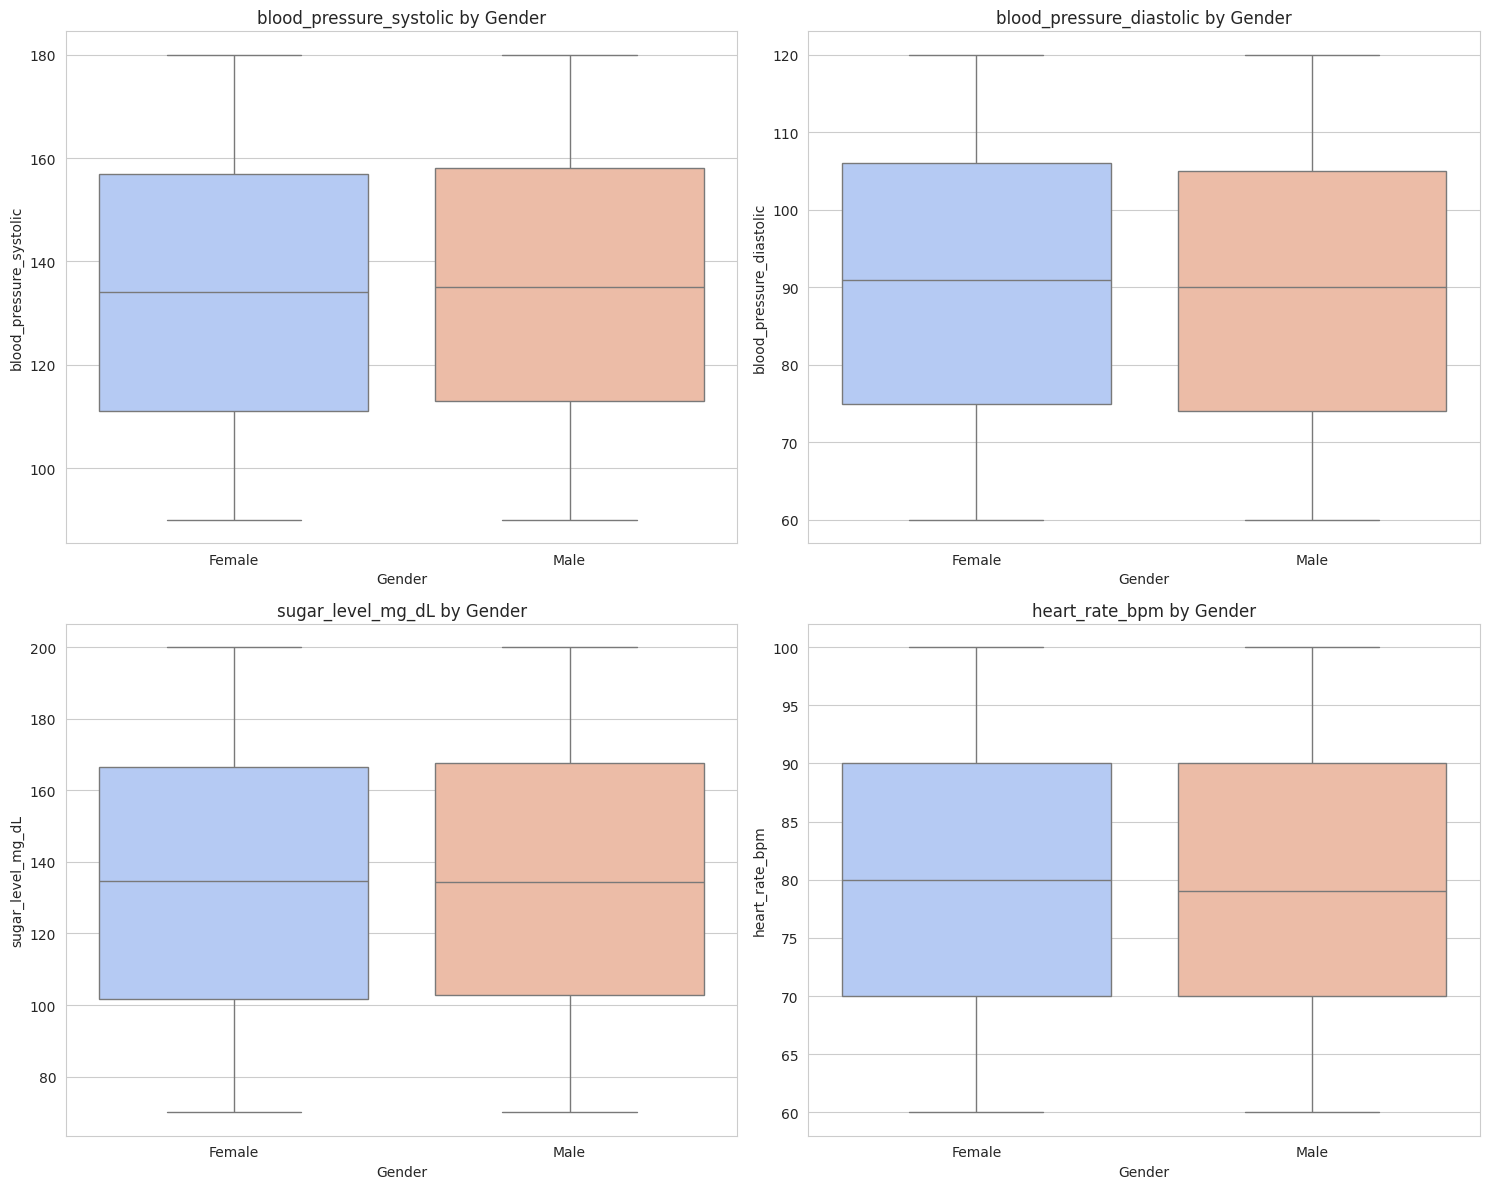

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

health_metrics = [
    'blood_pressure_systolic', 'blood_pressure_diastolic',
    'sugar_level_mg_dL', 'heart_rate_bpm'
]

for i, col in enumerate(health_metrics):
    sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

/tmp/ipykernel_860/929790675.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_860/929790675.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_860/929790675.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')


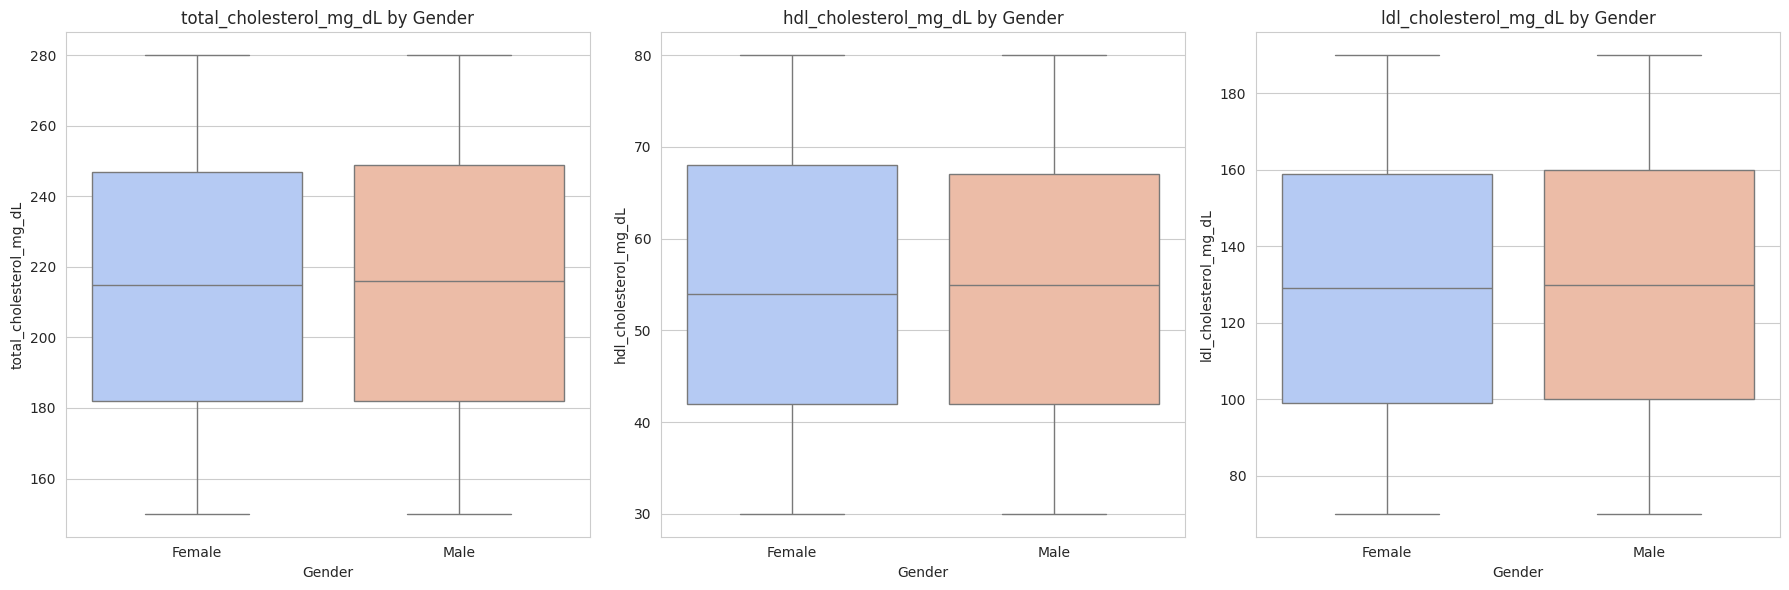

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
axes = axes.flatten()

cholesterol_metrics = [
    'total_cholesterol_mg_dL', 'hdl_cholesterol_mg_dL', 'ldl_cholesterol_mg_dL'
]

for i, col in enumerate(cholesterol_metrics):
    sns.boxplot(x='gender', y=col, data=df_patients, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [24]:
gender_stats = df_patients.groupby('gender')[numerical_cols].mean()
print("Average Health Metrics by Gender:")
display(gender_stats)

Average Health Metrics by Gender:


,age,blood_pressure_systolic,blood_pressure_diastolic,sugar_level_mg_dL,total_cholesterol_mg_dL,hdl_cholesterol_mg_dL,ldl_cholesterol_mg_dL,heart_rate_bpm
gender,,,,,,,,
Female,54.476431,134.237912,90.625733,134.257779,214.680558,54.731135,129.838560,80.039045
Male,53.674708,135.238284,89.877793,134.918351,215.578802,54.791378,130.131699,79.647815


In [25]:
# Specific checks for numerical columns based on generation ranges

# Age: 18-90
age_outliers = df_patients[(df_patients['age'] < 18) | (df_patients['age'] > 90)]
print(f"\nAge values outside expected range (18-90): {len(age_outliers)}")

# Blood Pressure Systolic: 90-180, Diastolic: 60-120
bp_systolic_outliers = df_patients[(df_patients['blood_pressure_systolic'] < 90) | (df_patients['blood_pressure_systolic'] > 180)]
print(f"Blood Pressure Systolic values outside expected range (90-180): {len(bp_systolic_outliers)}")
bp_diastolic_outliers = df_patients[(df_patients['blood_pressure_diastolic'] < 60) | (df_patients['blood_pressure_diastolic'] > 120)]
print(f"Blood Pressure Diastolic values outside expected range (60-120): {len(bp_diastolic_outliers)}")

# Sugar Level: 70.0-200.0
sugar_outliers = df_patients[(df_patients['sugar_level_mg_dL'] < 70.0) | (df_patients['sugar_level_mg_dL'] > 200.0)]
print(f"Sugar Level values outside expected range (70.0-200.0): {len(sugar_outliers)}")

# Total Cholesterol: 150-280
total_chol_outliers = df_patients[(df_patients['total_cholesterol_mg_dL'] < 150) | (df_patients['total_cholesterol_mg_dL'] > 280)]
print(f"Total Cholesterol values outside expected range (150-280): {len(total_chol_outliers)}")

# HDL Cholesterol: 30-80
hdl_chol_outliers = df_patients[(df_patients['hdl_cholesterol_mg_dL'] < 30) | (df_patients['hdl_cholesterol_mg_dL'] > 80)]
print(f"HDL Cholesterol values outside expected range (30-80): {len(hdl_chol_outliers)}")

# LDL Cholesterol: 70-190
ldl_chol_outliers = df_patients[(df_patients['ldl_cholesterol_mg_dL'] < 70) | (df_patients['ldl_cholesterol_mg_dL'] > 190)]
print(f"LDL Cholesterol values outside expected range (70-190): {len(ldl_chol_outliers)}")

# Heart Rate: 60-100
heart_rate_outliers = df_patients[(df_patients['heart_rate_bpm'] < 60) | (df_patients['heart_rate_bpm'] > 100)]
print(f"Heart Rate values outside expected range (60-100): {len(heart_rate_outliers)}")


Age values outside expected range (18-90): 0
Blood Pressure Systolic values outside expected range (90-180): 0
Blood Pressure Diastolic values outside expected range (60-120): 0
Sugar Level values outside expected range (70.0-200.0): 0
Total Cholesterol values outside expected range (150-280): 0
HDL Cholesterol values outside expected range (30-80): 0
LDL Cholesterol values outside expected range (70-190): 0
Heart Rate values outside expected range (60-100): 0
